# Mindspace Voice Agent — EDA (Fresh)
Basic Exploratory Data Analysis on the Balanced Mental Health Dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("balanced-dataset.csv")
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Dataset loaded successfully!
Shape: (58956, 66)


## 1. Basic Dataset Info

In [2]:
print("=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print("\n=== Column Names ===")
print(df.columns.tolist())

print("\n=== Data Types ===")
print(df.dtypes.value_counts())

=== Shape ===
Rows: 58956, Columns: 66

=== Column Names ===
['profile', 'language', 'total_word_count', 'unique_word_count', 'ttr', 'positive_emotion_ratio', 'negative_emotion_ratio', 'fear_word_frequency', 'sadness_word_frequency', 'anger_word_frequency', 'uncertainty_word_frequency', 'filler_word_frequency', 'repetition_rate', 'rumination_phrase_frequency', 'semantic_coherence_score', 'language_model_perplexity', 'overall_sentiment_score', 'past_focus_ratio', 'present_focus_ratio', 'future_focus_ratio', 'noun_ratio', 'verb_ratio', 'adjective_ratio', 'adverb_ratio', 'avg_sentence_length', 'parse_tree_depth', 'topic_shift_frequency', 'self_reference_density', 'topic_0', 'topic_1', 'topic_2', 'topic_3', 'topic_4', 'emb_0', 'emb_1', 'emb_2', 'emb_3', 'emb_4', 'emb_5', 'emb_6', 'emb_7', 'emb_8', 'emb_9', 'emb_10', 'emb_11', 'emb_12', 'emb_13', 'emb_14', 'emb_15', 'emb_16', 'emb_17', 'emb_18', 'emb_19', 'emb_20', 'emb_21', 'emb_22', 'emb_23', 'emb_24', 'emb_25', 'emb_26', 'emb_27', 'emb_2

In [3]:
df.head(5)

,profile,language,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,...,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,target
0,Anxiety,english,357,218,0.612943,0.044384,0.037396,0.095208,0.024032,0.025739,...,-0.670595,-0.075618,0.638965,-0.290946,1.401530,-0.080001,-0.735523,-1.208655,0.837912,Anxiety
1,Anxiety,hindi,270,89,0.330099,0.047817,0.029790,0.055456,0.066829,0.018933,...,-1.544683,-1.279693,0.482249,1.156445,1.035539,-1.515679,0.057072,-0.646649,-0.806429,Anxiety
2,Suicidal_Tendency,marathi,290,89,0.308650,0.010902,0.197816,0.021213,0.192087,0.043667,...,-0.688953,-0.891771,-0.250765,0.331877,1.616940,0.275634,1.120785,-0.070343,1.713898,Suicidal_Tendency
3,Phobia,english,465,154,0.331052,0.053142,0.072703,0.078191,0.014125,0.006657,...,-0.628049,-0.067382,-0.308444,-0.382712,0.901059,-0.334728,1.239768,-0.062887,-0.678398,Phobia
4,Depression,hindi,293,216,0.737136,0.016396,0.226110,0.052594,0.023402,0.012467,...,0.075476,-0.216873,0.046977,-1.076002,0.352232,0.426432,0.729224,0.411872,-0.947003,Depression


## 2. Missing Values & Duplicates

In [4]:
missing = df.isnull().sum()
print("=== Missing Values ===")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

print(f"\n=== Duplicate Rows ===")
print(f"Total duplicates: {df.duplicated().sum()}")

=== Missing Values ===
No missing values found!

=== Duplicate Rows ===
Total duplicates: 0


## 3. Class Distribution (Target Variable)

=== Class Distribution ===
target
Anxiety              9826
Suicidal_Tendency    9826
Phobia               9826
Depression           9826
Bipolar_Mania        9826
Stress               9826
Name: count, dtype: int64

Imbalance Ratio (max/min): 1.00


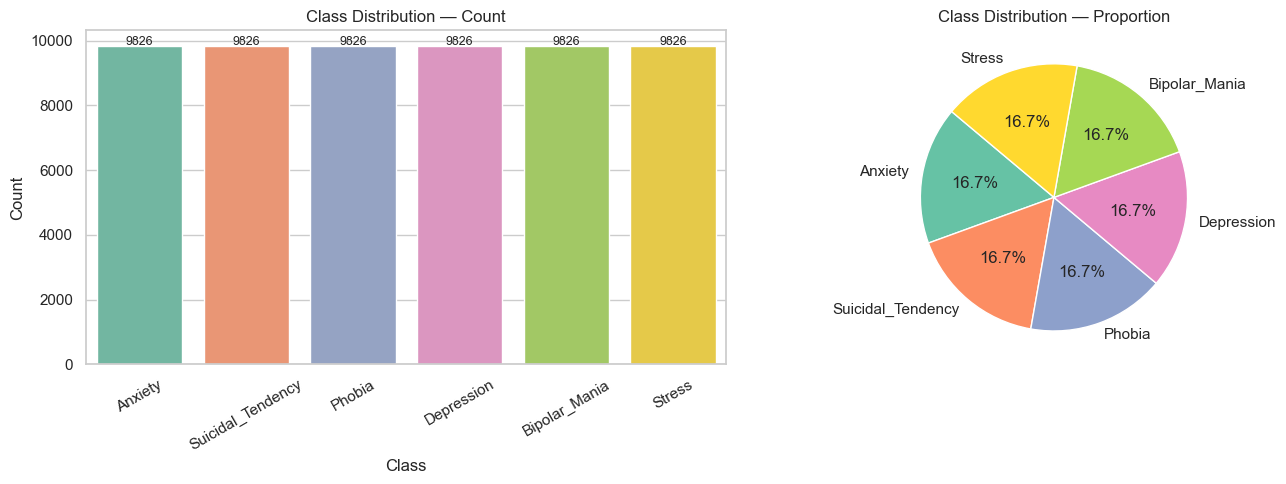

In [5]:
class_counts = df['target'].value_counts()
print("=== Class Distribution ===")
print(class_counts)
print(f"\nImbalance Ratio (max/min): {class_counts.max() / class_counts.min():.2f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=class_counts.index, y=class_counts.values, palette="Set2", ax=axes[0])
axes[0].set_title("Class Distribution — Count")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=30)
for bar, val in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(val), ha='center', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette("Set2", len(class_counts)), startangle=140)
axes[1].set_title("Class Distribution — Proportion")

plt.tight_layout()
plt.show()

## 4. Language Distribution

=== Language Distribution ===
language
english    26378
hindi      20699
marathi    11879
Name: count, dtype: int64


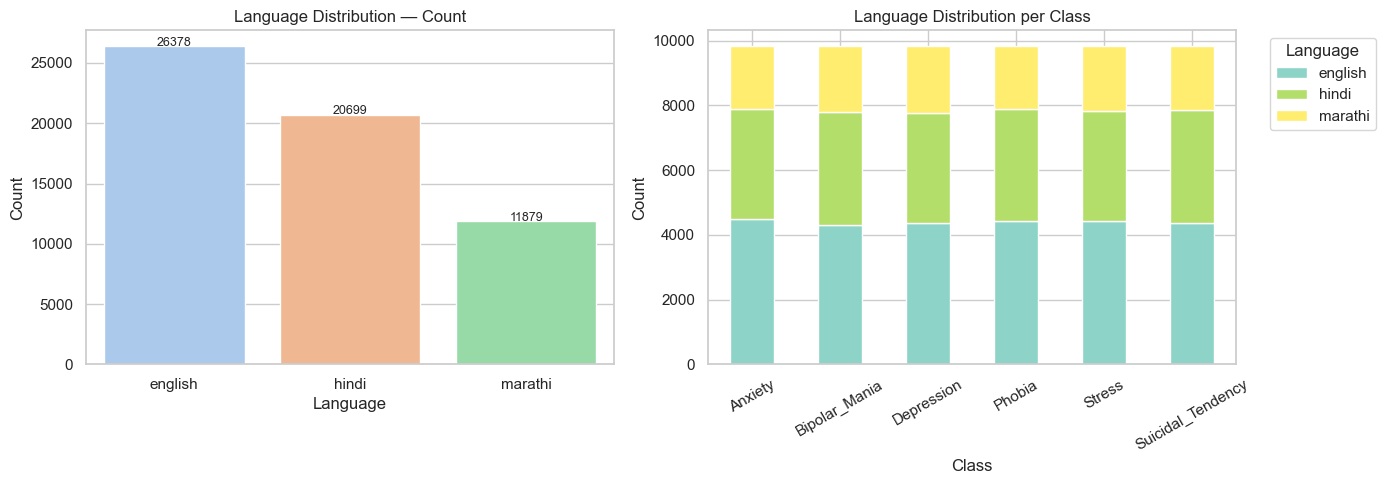

In [6]:
lang_counts = df['language'].value_counts()
print("=== Language Distribution ===")
print(lang_counts)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x=lang_counts.index, y=lang_counts.values, palette="pastel", ax=axes[0])
axes[0].set_title("Language Distribution — Count")
axes[0].set_xlabel("Language")
axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, lang_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, str(val), ha='center', fontsize=9)

# Language by class — stacked bar
lang_class = df.groupby(['target', 'language']).size().unstack(fill_value=0)
lang_class.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set3')
axes[1].set_title("Language Distribution per Class")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Language', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

## 5. Descriptive Statistics (Numeric Features)

In [7]:
# Focus on key linguistic features (exclude embeddings for readability)
linguistic_cols = [
    'total_word_count', 'unique_word_count', 'ttr',
    'positive_emotion_ratio', 'negative_emotion_ratio',
    'fear_word_frequency', 'sadness_word_frequency', 'anger_word_frequency',
    'uncertainty_word_frequency', 'filler_word_frequency',
    'semantic_coherence_score', 'overall_sentiment_score',
    'self_reference_density', 'future_focus_ratio', 'rumination_phrase_frequency'
]

df[linguistic_cols].describe().round(4)

,total_word_count,unique_word_count,ttr,positive_emotion_ratio,negative_emotion_ratio,fear_word_frequency,sadness_word_frequency,anger_word_frequency,uncertainty_word_frequency,filler_word_frequency,semantic_coherence_score,overall_sentiment_score,self_reference_density,future_focus_ratio,rumination_phrase_frequency
count,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000,58956.0000
mean,346.0862,173.5933,0.5021,0.0329,0.0726,0.0428,0.0519,0.0322,0.0464,0.0382,0.7043,-0.2430,0.0714,0.0698,0.0322
std,162.1433,92.8039,0.1167,0.0198,0.0499,0.0397,0.0444,0.0259,0.0336,0.0248,0.1346,0.3520,0.0429,0.0507,0.0262
min,50.0000,10.0000,0.2000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1942,-1.0000,0.0000,0.0000,0.0000
25%,237.0000,109.0000,0.4209,0.0164,0.0386,0.0166,0.0235,0.0147,0.0234,0.0209,0.6230,-0.3794,0.0424,0.0256,0.0146
50%,324.0000,157.0000,0.5011,0.0300,0.0619,0.0309,0.0393,0.0268,0.0386,0.0344,0.7240,-0.1426,0.0600,0.0614,0.0267
75%,423.0000,218.0000,0.5819,0.0468,0.0925,0.0532,0.0628,0.0417,0.0596,0.0499,0.8005,0.0043,0.0885,0.1047,0.0414
max,1272.0000,807.0000,0.8975,0.1198,0.3722,0.2792,0.3950,0.1973,0.2535,0.1995,0.9997,0.4704,0.3349,0.3645,0.2422


## 6. Distribution of Key Features (KDE Plots)

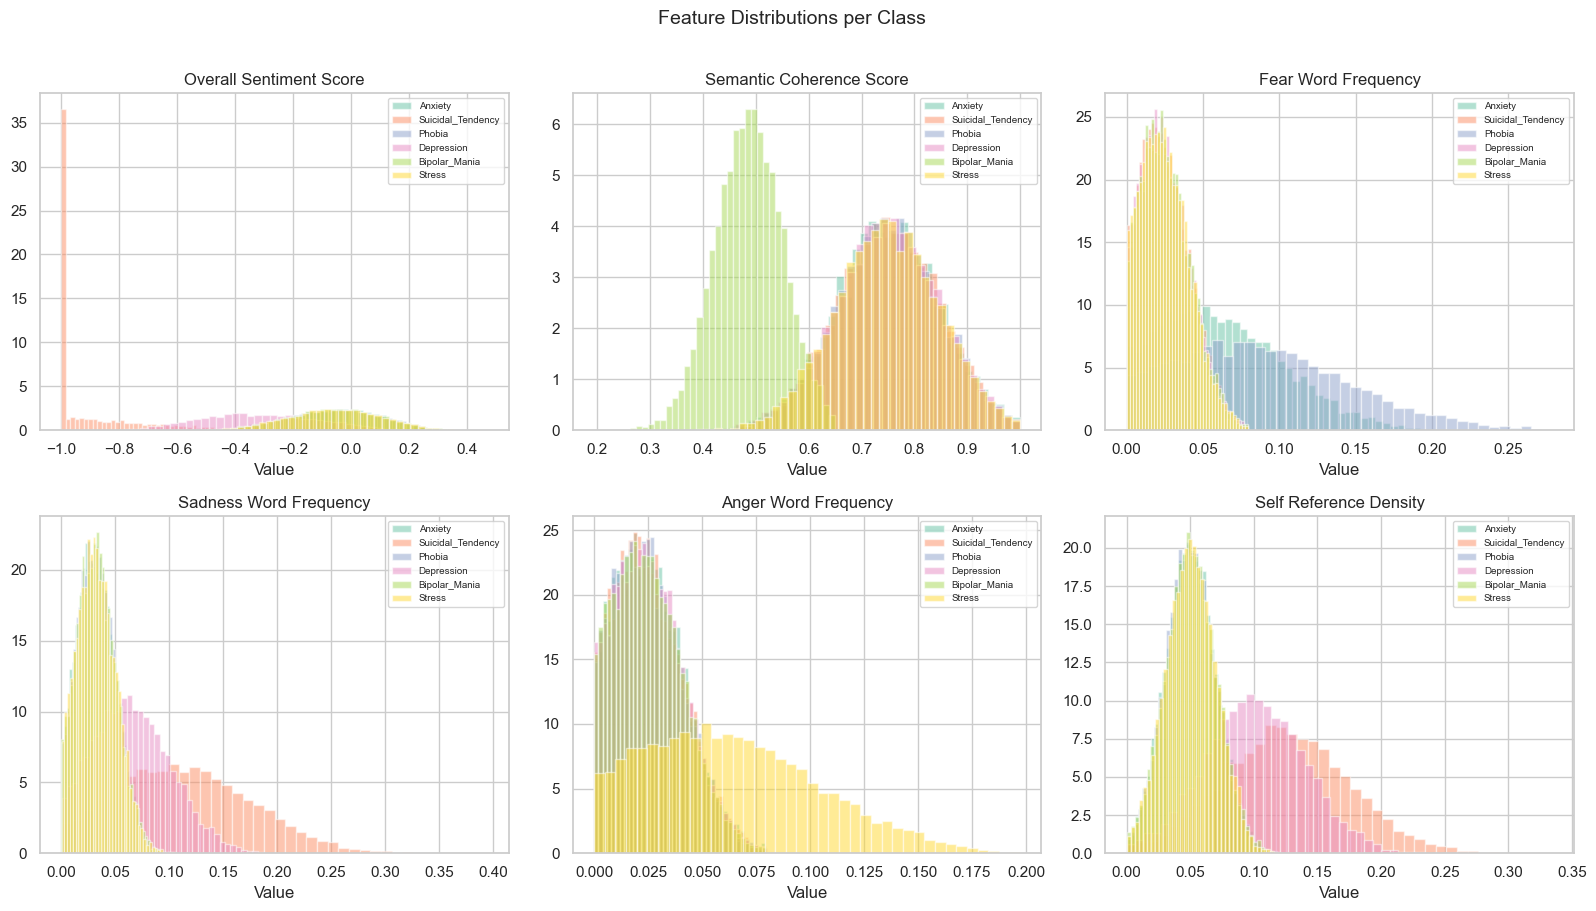

In [8]:
key_features = [
    'overall_sentiment_score', 'semantic_coherence_score',
    'fear_word_frequency', 'sadness_word_frequency',
    'anger_word_frequency', 'self_reference_density'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
palette = sns.color_palette("Set2", df['target'].nunique())

for i, col in enumerate(key_features):
    for j, cls in enumerate(df['target'].unique()):
        subset = df[df['target'] == cls][col]
        axes[i].hist(subset, bins=40, alpha=0.5, label=cls, color=palette[j], density=True)
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel("Value")
    axes[i].legend(fontsize=7)

plt.suptitle("Feature Distributions per Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Boxplots — Feature by Class

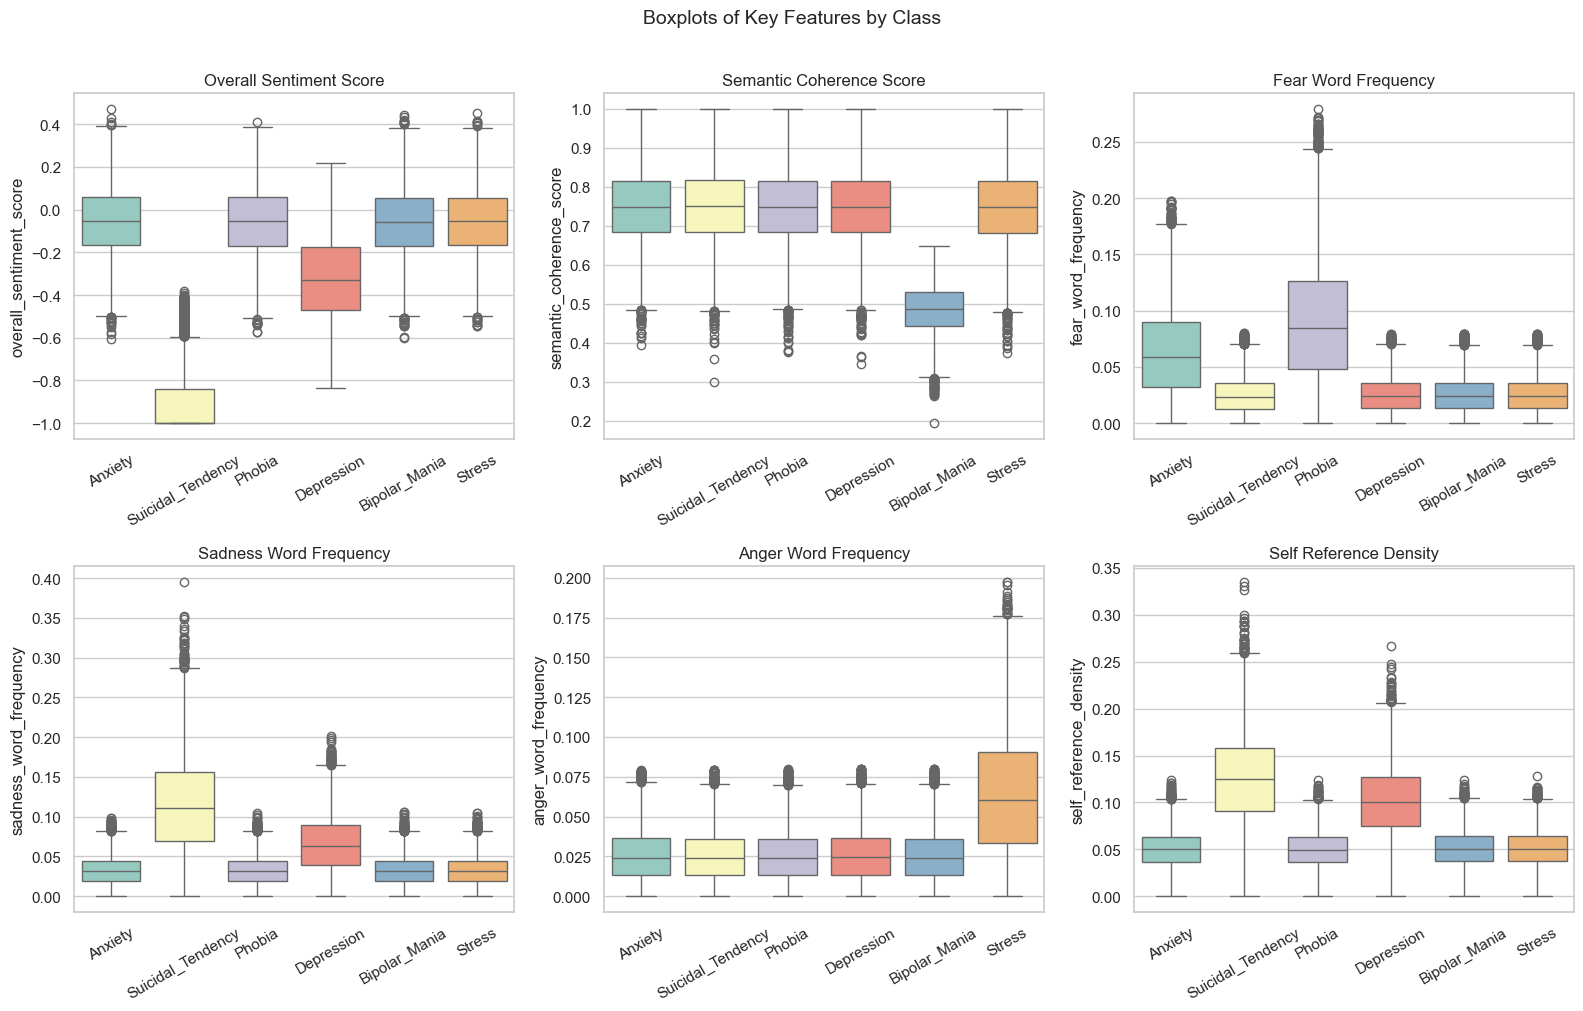

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    sns.boxplot(data=df, x='target', y=col, palette="Set3", ax=axes[i])
    axes[i].set_title(col.replace('_', ' ').title())
    axes[i].set_xlabel("")
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle("Boxplots of Key Features by Class", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. Correlation Heatmap (Linguistic Features)

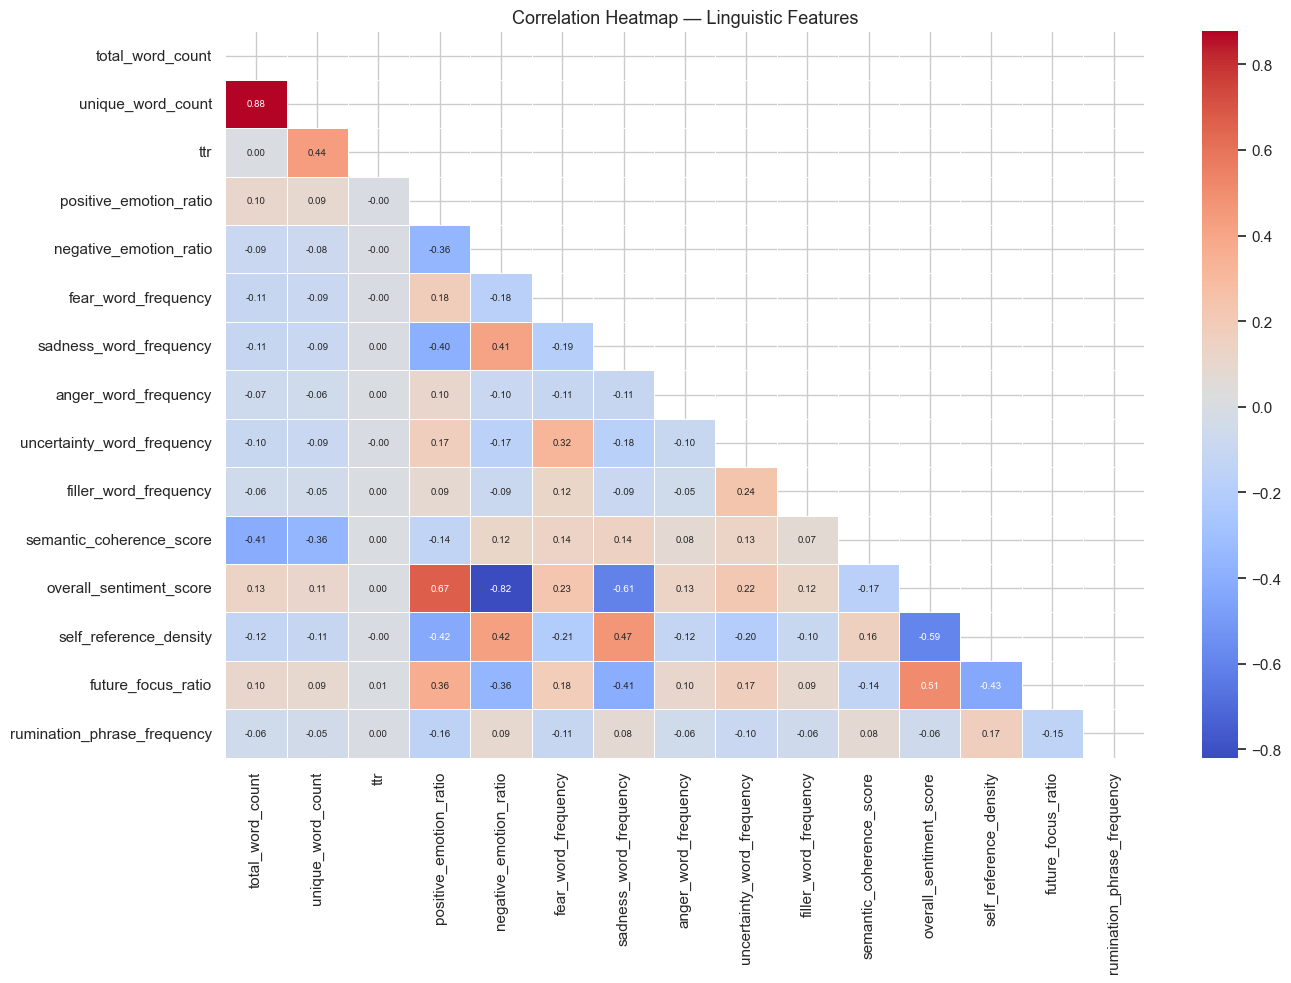

In [10]:
corr = df[linguistic_cols].corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 7})
plt.title("Correlation Heatmap — Linguistic Features", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Mean Feature Values per Class

                   overall_sentiment_score  semantic_coherence_score  \
target                                                                 
Anxiety                            -0.0559                    0.7479   
Bipolar_Mania                      -0.0598                    0.4858   
Depression                         -0.3216                    0.7477   
Phobia                             -0.0588                    0.7485   
Stress                             -0.0575                    0.7469   
Suicidal_Tendency                  -0.9043                    0.7491   

                   fear_word_frequency  sadness_word_frequency  \
target                                                           
Anxiety                         0.0637                  0.0327   
Bipolar_Mania                   0.0258                  0.0327   
Depression                      0.0257                  0.0656   
Phobia                          0.0905                  0.0327   
Stress                     

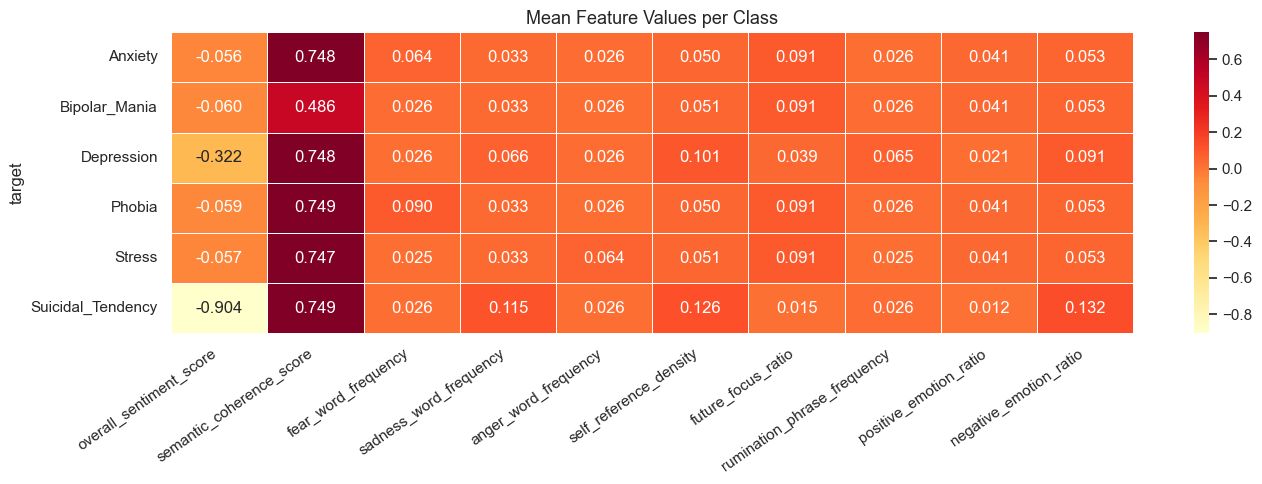

In [11]:
heatmap_features = [
    'overall_sentiment_score', 'semantic_coherence_score',
    'fear_word_frequency', 'sadness_word_frequency',
    'anger_word_frequency', 'self_reference_density',
    'future_focus_ratio', 'rumination_phrase_frequency',
    'positive_emotion_ratio', 'negative_emotion_ratio'
]

class_means = df.groupby('target')[heatmap_features].mean()
print(class_means.round(4))

plt.figure(figsize=(14, 5))
sns.heatmap(class_means, annot=True, fmt=".3f", cmap="YlOrRd", linewidths=0.5)
plt.title("Mean Feature Values per Class", fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 10. Word Count Distribution per Class

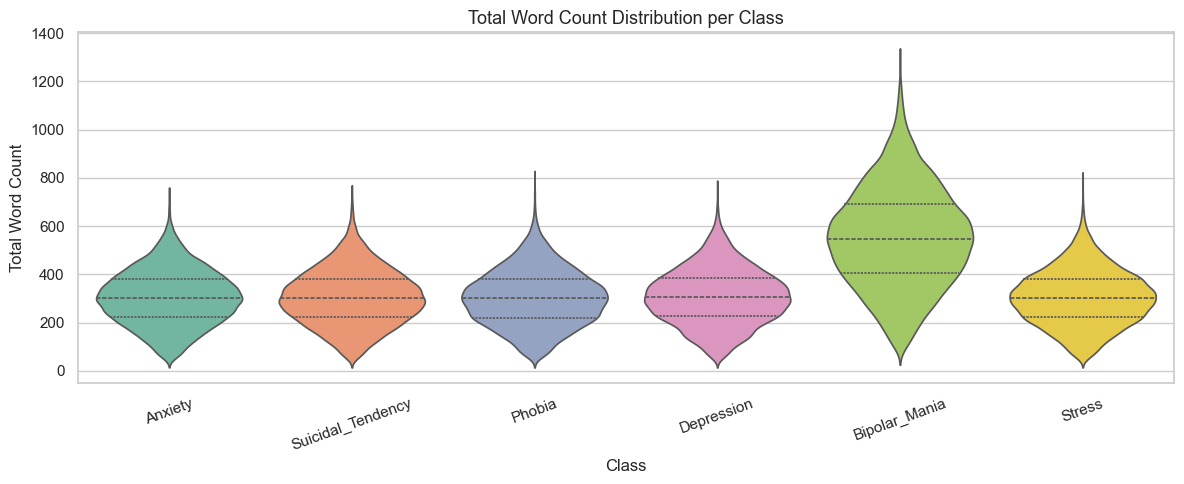


Median word count per class:
target
Bipolar_Mania        547.0
Depression           305.0
Anxiety              302.0
Stress               302.0
Phobia               300.0
Suicidal_Tendency    300.0
Name: total_word_count, dtype: float64


In [12]:
plt.figure(figsize=(12, 5))
sns.violinplot(data=df, x='target', y='total_word_count', palette="Set2", inner='quartile')
plt.title("Total Word Count Distribution per Class", fontsize=13)
plt.xlabel("Class")
plt.ylabel("Total Word Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("\nMedian word count per class:")
print(df.groupby('target')['total_word_count'].median().sort_values(ascending=False))

## 11. Sentiment Score per Class

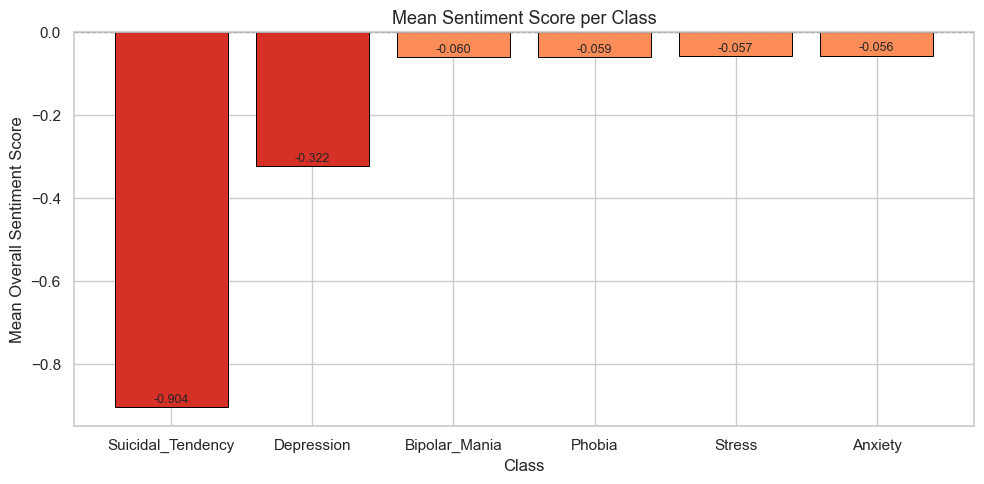

In [13]:
mean_sentiment = df.groupby('target')['overall_sentiment_score'].mean().sort_values()

plt.figure(figsize=(10, 5))
colors = ['#d73027' if v < -0.3 else '#fc8d59' if v < 0 else '#91bfdb' for v in mean_sentiment.values]
bars = plt.bar(mean_sentiment.index, mean_sentiment.values, color=colors, edgecolor='black', linewidth=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.title("Mean Sentiment Score per Class", fontsize=13)
plt.ylabel("Mean Overall Sentiment Score")
plt.xlabel("Class")
for bar, val in zip(bars, mean_sentiment.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{val:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 12. Summary Statistics Table

In [15]:
print("=== Quick Summary ===")
print(f"Total Samples       : {len(df):,}")
print(f"Total Features      : {df.shape[1]}")
print(f"Target Classes      : {df['target'].nunique()} ({', '.join(df['target'].unique())})")
print(f"Languages           : {df['language'].nunique()} ({', '.join(df['language'].unique())})")
print(f"Missing Values      : {df.isnull().sum().sum()}")
print(f"Duplicate Rows      : {df.duplicated().sum()}")
print(f"\nClass Counts:")
for cls, cnt in df['target'].value_counts().items():
    pct = cnt / len(df) * 100
    print(f"  {cls:<20} {cnt:>6,}  ({pct:.1f}%)")
print(f"\nImbalance Ratio     : {df['target'].value_counts().max() / df['target'].value_counts().min():.2f}x")

=== Quick Summary ===
Total Samples       : 58,956
Total Features      : 66
Target Classes      : 6 (Anxiety, Suicidal_Tendency, Phobia, Depression, Bipolar_Mania, Stress)
Languages           : 3 (english, hindi, marathi)
Missing Values      : 0
Duplicate Rows      : 0

Class Counts:
  Anxiety               9,826  (16.7%)
  Suicidal_Tendency     9,826  (16.7%)
  Phobia                9,826  (16.7%)
  Depression            9,826  (16.7%)
  Bipolar_Mania         9,826  (16.7%)
  Stress                9,826  (16.7%)

Imbalance Ratio     : 1.00x


## 13. Feature Importance Analysis — Predicting Mental State

> **Goal:** Identify which features contribute most to classifying a person's mental state.
>
> We use three complementary methods:
> - **Random Forest Feature Importance** — measures average impurity reduction across trees
> - **Permutation Importance** — measures accuracy drop when a feature is randomly shuffled
> - **Mutual Information** — measures statistical dependency between each feature and the target class
>
> Comparing all three gives a robust picture of which features are truly predictive.

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ── 1. Prepare data ──────────────────────────────────────────────────────────
# Select all numeric columns except target-related or ID columns
exclude = {'target', 'language', 'text', 'id'}
feature_cols = [c for c in df.columns if c not in exclude and pd.api.types.is_numeric_dtype(df[c])]

X = df[feature_cols].fillna(0)
le = LabelEncoder()
y = le.fit_transform(df['target'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Features used : {len(feature_cols)}")
print(f"Classes       : {list(le.classes_)}")

Features used : 63
Classes       : ['Anxiety', 'Bipolar_Mania', 'Depression', 'Phobia', 'Stress', 'Suicidal_Tendency']


In [17]:
# ── 2. Train Random Forest ───────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=300, max_depth=None, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"RF Train Accuracy : {rf.score(X_train, y_train):.4f}")
print(f"RF Test  Accuracy : {rf.score(X_test,  y_test):.4f}")

RF Train Accuracy : 1.0000
RF Test  Accuracy : 0.9136


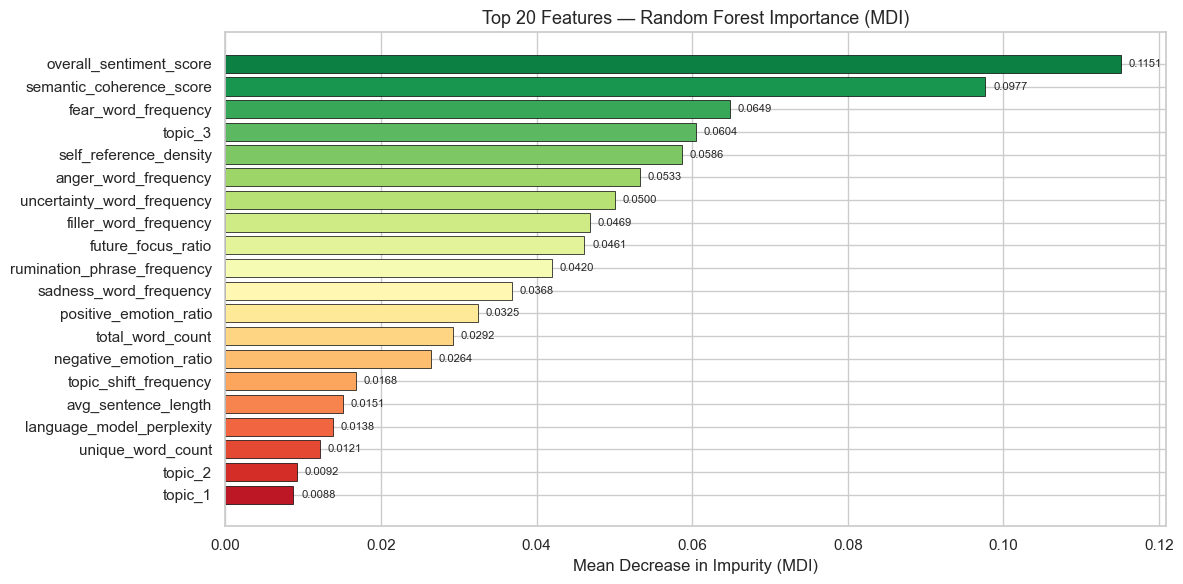

In [19]:
# ── 3. Random Forest Feature Importance (MDI) ────────────────────────────────
rf_imp = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
top_n = 20
top_rf = rf_imp.head(top_n)

plt.figure(figsize=(12, 6))
colors = sns.color_palette("RdYlGn_r", top_n)
bars = plt.barh(top_rf.index[::-1], top_rf.values[::-1], color=colors[::-1], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars, top_rf.values[::-1]):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center', fontsize=8)
plt.xlabel("Mean Decrease in Impurity (MDI)")
plt.title(f"Top {top_n} Features — Random Forest Importance (MDI)", fontsize=13)
plt.tight_layout()
plt.show()

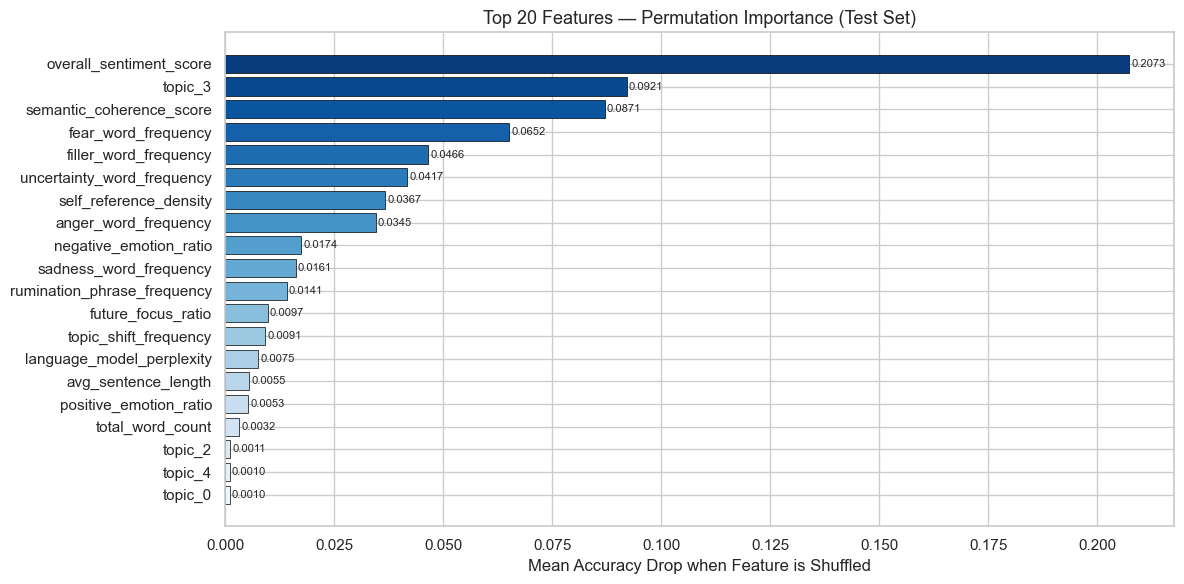

In [20]:
# ── 4. Permutation Importance (on test set — less biased than MDI) ───────────
perm = permutation_importance(rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
perm_imp = pd.Series(perm.importances_mean, index=feature_cols).sort_values(ascending=False)
top_perm = perm_imp.head(top_n)

plt.figure(figsize=(12, 6))
colors_p = sns.color_palette("Blues_r", top_n)
bars_p = plt.barh(top_perm.index[::-1], top_perm.values[::-1], color=colors_p[::-1], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars_p, top_perm.values[::-1]):
    plt.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center', fontsize=8)
plt.xlabel("Mean Accuracy Drop when Feature is Shuffled")
plt.title(f"Top {top_n} Features — Permutation Importance (Test Set)", fontsize=13)
plt.tight_layout()
plt.show()

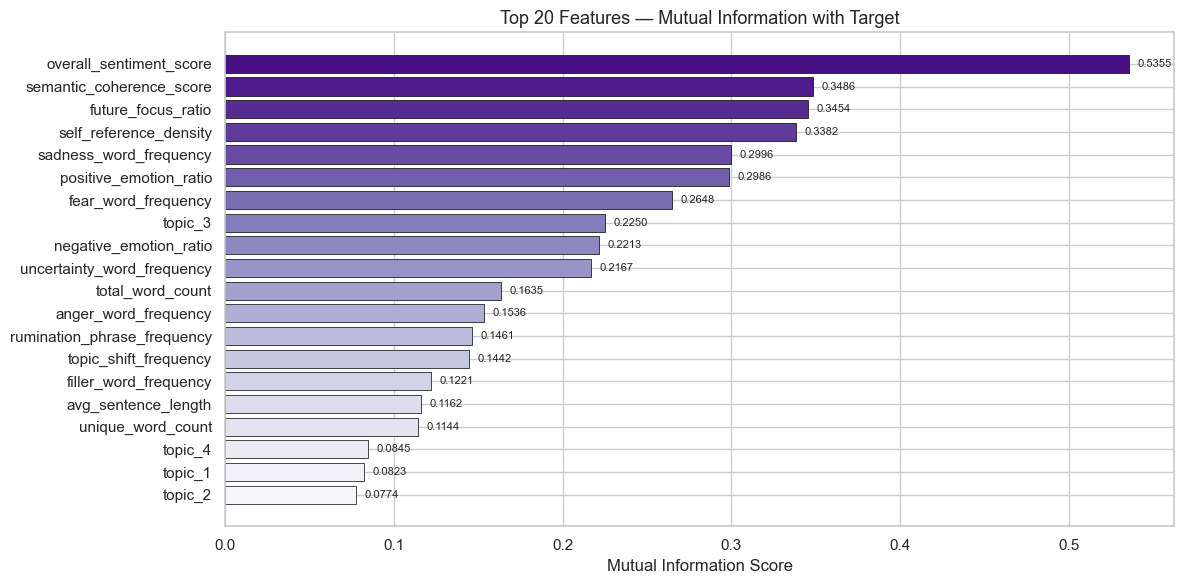

In [21]:
# ── 5. Mutual Information ────────────────────────────────────────────────────
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_imp = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)
top_mi = mi_imp.head(top_n)

plt.figure(figsize=(12, 6))
colors_m = sns.color_palette("Purples_r", top_n)
bars_m = plt.barh(top_mi.index[::-1], top_mi.values[::-1], color=colors_m[::-1], edgecolor='black', linewidth=0.5)
for bar, val in zip(bars_m, top_mi.values[::-1]):
    plt.text(val + 0.005, bar.get_y() + bar.get_height()/2, f"{val:.4f}", va='center', fontsize=8)
plt.xlabel("Mutual Information Score")
plt.title(f"Top {top_n} Features — Mutual Information with Target", fontsize=13)
plt.tight_layout()
plt.show()

=== Top 20 Most Predictive Features (Consensus Ranking) ===

                             avg_rank  RF_MDI  Perm_imp  MI_score
overall_sentiment_score        1.0000  0.1151    0.2073    0.5355
semantic_coherence_score       2.3333  0.0977    0.0871    0.3486
fear_word_frequency            4.6667  0.0649    0.0652    0.2648
topic_3                        4.6667  0.0604    0.0921    0.2250
self_reference_density         5.3333  0.0586    0.0367    0.3382
uncertainty_word_frequency     7.6667  0.0500    0.0417    0.2167
future_focus_ratio             8.0000  0.0461    0.0097    0.3454
anger_word_frequency           8.6667  0.0533    0.0345    0.1536
sadness_word_frequency         8.6667  0.0368    0.0161    0.2996
filler_word_frequency          9.3333  0.0469    0.0466    0.1221
negative_emotion_ratio        10.6667  0.0264    0.0174    0.2213
rumination_phrase_frequency   11.3333  0.0420    0.0141    0.1461
positive_emotion_ratio        11.3333  0.0325    0.0053    0.2986
total_word_coun

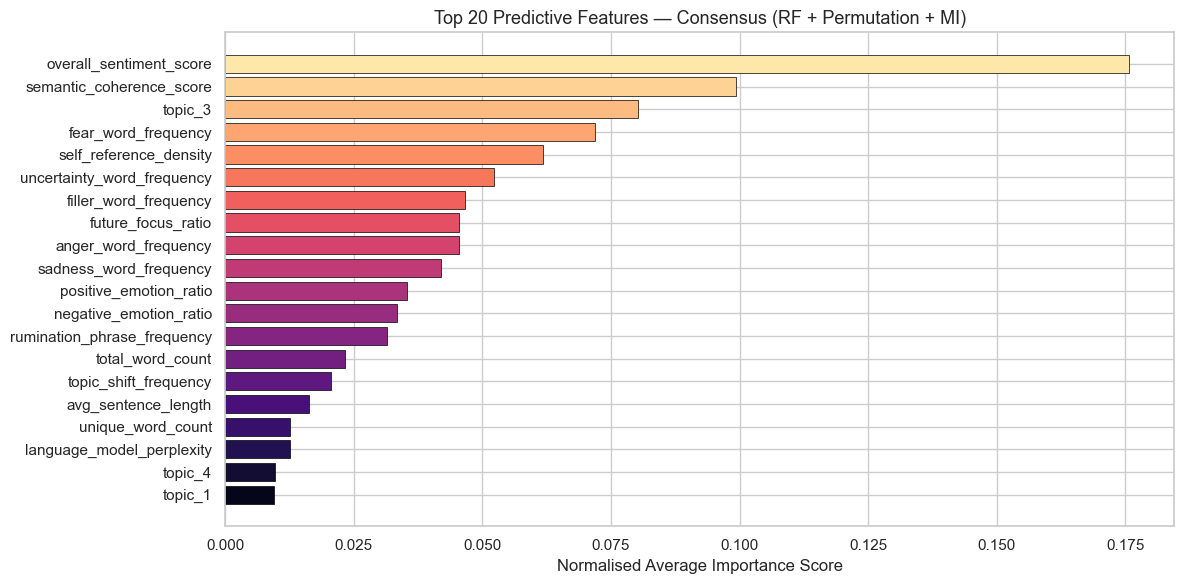

In [22]:
# ── 6. Consensus Ranking — Average Rank across all 3 methods ─────────────────
rank_rf   = rf_imp.rank(ascending=False).rename("RF_MDI_rank")
rank_perm = perm_imp.rank(ascending=False).rename("Perm_rank")
rank_mi   = mi_imp.rank(ascending=False).rename("MI_rank")

ranking_df = pd.concat([rank_rf, rank_perm, rank_mi], axis=1)
ranking_df["avg_rank"] = ranking_df.mean(axis=1)
ranking_df = ranking_df.sort_values("avg_rank")

# Attach raw scores for display
ranking_df["RF_MDI"]   = rf_imp
ranking_df["Perm_imp"] = perm_imp
ranking_df["MI_score"] = mi_imp

top_consensus = ranking_df.head(top_n)

print(f"=== Top {top_n} Most Predictive Features (Consensus Ranking) ===\n")
display_cols = ["avg_rank", "RF_MDI", "Perm_imp", "MI_score"]
print(top_consensus[display_cols].round(4).to_string())

# Visual — consensus bar chart
plt.figure(figsize=(12, 6))
score_avg = (
    (rf_imp / rf_imp.sum()) +
    (perm_imp.clip(lower=0) / perm_imp.clip(lower=0).sum()) +
    (mi_imp / mi_imp.sum())
) / 3
score_avg_top = score_avg.nlargest(top_n).sort_values()

palette_c = sns.color_palette("magma", top_n)
plt.barh(score_avg_top.index, score_avg_top.values, color=palette_c, edgecolor='black', linewidth=0.5)
plt.xlabel("Normalised Average Importance Score")
plt.title(f"Top {top_n} Predictive Features — Consensus (RF + Permutation + MI)", fontsize=13)
plt.tight_layout()
plt.show()

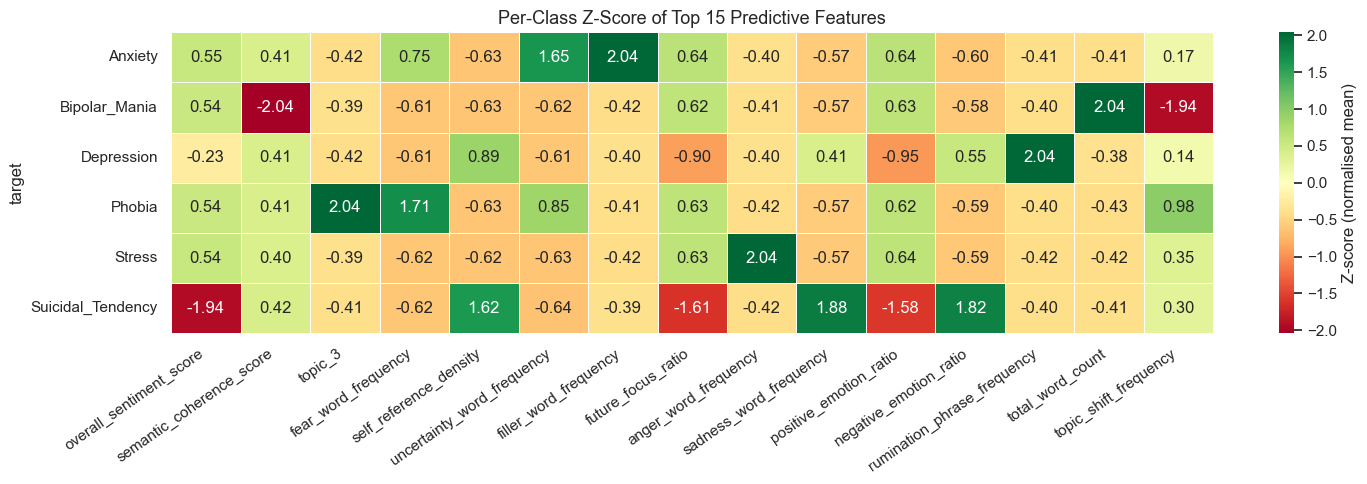

In [23]:
# ── 7. Per-Class Contribution of Top Features (heatmap) ──────────────────────
top_feature_names = score_avg.nlargest(15).index.tolist()

class_means_top = df.groupby('target')[top_feature_names].mean()

# Z-score normalise per feature so scale differences don't dominate
class_means_z = (class_means_top - class_means_top.mean()) / (class_means_top.std() + 1e-9)

plt.figure(figsize=(15, 5))
sns.heatmap(
    class_means_z,
    annot=True, fmt=".2f",
    cmap="RdYlGn",
    linewidths=0.5,
    cbar_kws={"label": "Z-score (normalised mean)"}
)
plt.title("Per-Class Z-Score of Top 15 Predictive Features", fontsize=13)
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()